---
# Ley de Benford

La Ley de Benford es un principio matemático que describe un patrón muy interesante en los conjuntos de números naturales, como los que se encuentran en bases de datos financieras, poblaciones, medidas, etc. Esta ley dice que, en muchas listas de números reales que ocurren naturalmente, como los ingresos de las personas o los números que aparecen en los censos, el primer dígito significativo no es igualmente probable para todos los números. En cambio, los números tienden a comenzar más frecuentemente con dígitos más pequeños, como 1, 2 o 3, en lugar de dígitos más grandes, como 8 o 9.

Por ejemplo, si tienes una lista de números que representan los ingresos de varias personas, es más probable que encuentres más personas con ingresos que comienzan con 1 o 2 (como 1000 o 2500 dólares) que con ingresos que comienzan con 8 o 9 (como 8500 o 9500 dólares).

Este patrón puede ser útil para detectar posibles anomalías o fraudes en datos financieros, ya que los conjuntos de datos que violan la Ley de Benford podrían indicar manipulación o errores en la información. En resumen, la Ley de Benford es una regla matemática interesante que muestra cómo los números reales tienden a comportarse en la naturaleza.

Para más información:
https://en.wikipedia.org/wiki/Benford%27s_law

video extra: https://www.youtube.com/watch?v=yyiQ1i3USPo


In [49]:
import pandas as pd
import math
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv('SPY.csv', index_col='Date', parse_dates=True)

In [51]:
df.head(2)

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1993-01-29,43.9687,43.9687,43.7500,43.9375,1003200,28.000838
1993-02-01,43.9687,44.2500,43.9687,44.2500,480500,28.199990


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6026 entries, 1993-01-29 to 2016-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       6026 non-null   float64
 1   High       6026 non-null   float64
 2   Low        6026 non-null   float64
 3   Close      6026 non-null   float64
 4   Volume     6026 non-null   int64  
 5   Adj Close  6026 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 329.5 KB


In [53]:
# creamos una columna con el retorno, que correspondería al precio de cierre del día menos el precio de cierre del día anterior
df['Margen'] = df.Close/df.Close.shift()-1

In [54]:
df.head(10)

,Open,High,Low,Close,Volume,Adj Close,Margen
Date,,,,,,,
1993-01-29,43.9687,43.9687,43.7500,43.9375,1003200,28.000838,NaN
1993-02-01,43.9687,44.2500,43.9687,44.2500,480500,28.199990,0.007112
1993-02-02,44.2187,44.3750,44.1250,44.3437,201300,28.259704,0.002118
1993-02-03,44.4062,44.8437,44.3750,44.8125,529400,28.558465,0.010572
1993-02-04,44.9687,45.0937,44.4687,45.0000,531500,28.677956,0.004184
1993-02-05,44.9687,45.0625,44.7187,44.9687,492100,28.658009,-0.000696
1993-02-08,44.9687,45.1250,44.9062,44.9687,596100,28.658009,0.000000
1993-02-09,44.8125,44.8125,44.5625,44.6562,122100,28.458857,-0.006949
1993-02-10,44.6562,44.7500,44.5312,44.7187,379600,28.498687,0.001400


In [55]:
def extract_first_digit(number):
    if pd.isnull(number):
        return math.nan
    else:
        s = str(float(str(abs(number)).replace('.','')))[0]
        return math.nan if s=='0' else s


In [56]:
df['first_digit'] = df['Margen'].apply(extract_first_digit)


In [57]:
df.head()

,Open,High,Low,Close,Volume,Adj Close,Margen,first_digit
Date,,,,,,,,
1993-01-29,43.9687,43.9687,43.7500,43.9375,1003200,28.000838,NaN,NaN
1993-02-01,43.9687,44.2500,43.9687,44.2500,480500,28.199990,0.007112,7
1993-02-02,44.2187,44.3750,44.1250,44.3437,201300,28.259704,0.002118,2
1993-02-03,44.4062,44.8437,44.3750,44.8125,529400,28.558465,0.010572,1
1993-02-04,44.9687,45.0937,44.4687,45.0000,531500,28.677956,0.004184,4


In [58]:
def benford_proportion(first_digit):
    """
    returns the likelihood (between 0 and 1) that the first digit
    of any number you are looking at starts with n, according to
    Benford's law. n should be between 1 and 9
    """
    if not isinstance(first_digit, int) or first_digit < 1 or first_digit > 9:
        raise ValueError("n should be an integer between 1 and 9")

    likelihood = math.log10((first_digit+1)/first_digit)
    return likelihood

In [59]:
# value counts nos puede ayudar a calcular la Frecuencia de Ocurrencia de cada digito
df['first_digit'].value_counts()

,count
first_digit,
1,1830
2,956
3,664
4,535
5,488
6,451
7,387
8,342
9,315


In [60]:
# Sin embargo, más nos sirve si lo normalizamos (Frecuencia Relativa)
df['first_digit'].value_counts(normalize=True)

,proportion
first_digit,
1,0.306635
2,0.160188
3,0.111260
4,0.089645
5,0.081769
6,0.075570
7,0.064846
8,0.057306
9,0.052782


In [61]:
df.head()

,Open,High,Low,Close,Volume,Adj Close,Margen,first_digit
Date,,,,,,,,
1993-01-29,43.9687,43.9687,43.7500,43.9375,1003200,28.000838,NaN,NaN
1993-02-01,43.9687,44.2500,43.9687,44.2500,480500,28.199990,0.007112,7
1993-02-02,44.2187,44.3750,44.1250,44.3437,201300,28.259704,0.002118,2
1993-02-03,44.4062,44.8437,44.3750,44.8125,529400,28.558465,0.010572,1
1993-02-04,44.9687,45.0937,44.4687,45.0000,531500,28.677956,0.004184,4


In [62]:
# Ahora creamos un dataframe con la probabilidad calculada de la Ley de Benford y nuestra frecuencia relativa (Probabilidad Empírica)
res = pd.DataFrame(df['first_digit'].value_counts(normalize=True)) \
        .rename(columns={'first_digit':'Prob Empirica'})
res['Prob Teorica'] = [benford_proportion(n) for n in range(1,10)]

In [63]:
res

,proportion,Prob Teorica
first_digit,,
1,0.306635,0.301030
2,0.160188,0.176091
3,0.111260,0.124939
4,0.089645,0.096910
5,0.081769,0.079181
6,0.075570,0.066947
7,0.064846,0.057992
8,0.057306,0.051153
9,0.052782,0.045757


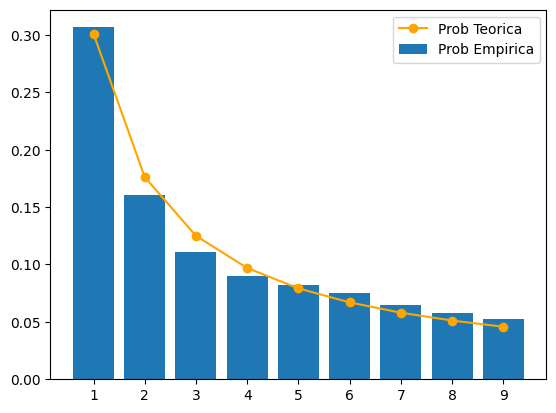

In [64]:
plt.plot(res['Prob Teorica'], marker='o', c='orange', label='Prob Teorica')
plt.bar(res.index, res['proportion'], label='Prob Empirica')
plt.legend(loc=0)

---